# 🎬 Automated Content Briefing System
### ThinkFlix ML Challenge
This notebook transforms a long-form article into a structured multimedia briefing with audio narration and a final video.

## Step 1: Install Dependencies

In [1]:
# Run this cell once
!pip install sumy edge-tts moviepy matplotlib pillow nltk imageio imageio-ffmpeg nest_asyncio

In [2]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Owner\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Owner\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Owner\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Step 2: Input Article

In [11]:
ARTICLE_TITLE = "The Rise of Electric Vehicles"

ARTICLE_TEXT = """
Electric vehicles, commonly known as EVs, are transforming the global automotive industry at an
unprecedented pace. Once considered a niche technology reserved for early adopters and environmental
enthusiasts, electric vehicles have now entered the mainstream, reshaping how people think about
transportation, energy, and the future of our planet.

The history of electric vehicles is older than most people realize. The first practical electric
cars appeared in the late 1800s, and for a brief period around 1900, electric vehicles outsold
gasoline-powered cars in the United States. However, the discovery of vast oil reserves and the
mass production of affordable gasoline vehicles, pioneered by Henry Ford, pushed electric cars
to the margins for nearly a century. It was not until the 1990s and early 2000s, driven by
growing environmental concerns and advances in battery technology, that serious interest in
electric vehicles was rekindled.

The modern electric vehicle era truly began with Tesla. Founded in 2003, Tesla demonstrated that
electric vehicles could be desirable, high-performance machines rather than slow, limited
compromises. The launch of the Tesla Roadster in 2008, followed by the Model S in 2012, proved
that EVs could compete with and even outperform traditional luxury sports cars. Tesla's success
forced the entire automotive industry to take electric vehicles seriously, triggering a wave of
investment and development that continues to accelerate today.

At the heart of the EV revolution is battery technology. Lithium-ion batteries, the same
technology that powers smartphones and laptops, have become the standard for electric vehicles.
Over the past decade, the cost of lithium-ion battery packs has fallen by more than 90 percent,
making electric vehicles increasingly affordable. Researchers are actively developing next-generation
solid-state batteries, which promise even greater energy density, faster charging, and improved
safety compared to current lithium-ion technology. These advances could eliminate range anxiety,
one of the primary concerns that has slowed EV adoption.

Range anxiety, the fear of running out of battery charge before reaching a destination, remains
a significant psychological barrier for many potential EV buyers. However, modern electric vehicles
have largely overcome this challenge in practical terms. The average new electric vehicle now
offers a range of over 300 miles on a single charge, which is more than sufficient for the
daily driving needs of the vast majority of people. Fast charging networks, led by Tesla's
Supercharger network and growing competitors like Electrify America, can add hundreds of miles
of range in as little as 20 to 30 minutes, making long-distance travel increasingly practical.

Government policy has played a crucial role in accelerating the adoption of electric vehicles
worldwide. Many countries have introduced generous purchase incentives, tax credits, and rebates
to lower the upfront cost of EVs for consumers. In the United States, the Inflation Reduction Act
provides tax credits of up to seven thousand five hundred dollars for qualifying electric vehicle
purchases. The European Union has set ambitious targets to end the sale of new gasoline and diesel
cars by 2035. China, the world's largest automotive market, has implemented aggressive EV mandates
and subsidies, making it the global leader in both EV production and sales.

The environmental case for electric vehicles is compelling, though nuanced. EVs produce zero
direct tailpipe emissions, significantly improving air quality in cities. Over their full lifecycle,
including manufacturing and electricity generation, electric vehicles produce substantially fewer
greenhouse gas emissions than gasoline-powered cars in most parts of the world. As electricity
grids become cleaner through the growth of renewable energy sources like solar and wind power,
the environmental benefits of electric vehicles will only increase.

The rise of electric vehicles is also driving major changes in the energy sector. EV charging is
creating new demand for electricity, spurring investment in grid infrastructure and renewable
energy generation. Smart charging technologies are being developed that allow EV batteries to
draw power during off-peak hours when electricity is cheaper and cleaner. Vehicle-to-grid
technology, which allows EV batteries to send power back to the grid during periods of high
demand, could transform electric vehicles into mobile energy storage assets that help stabilize
the power grid.

The economic impact of the EV transition is profound and far-reaching. The automotive supply
chain is being fundamentally restructured, with demand surging for lithium, cobalt, nickel, and
other battery materials. Traditional auto workers face uncertainty as electric vehicles require
fewer parts and less labor to manufacture than combustion engine vehicles. At the same time,
entirely new industries and job categories are emerging around battery production, charging
infrastructure, and EV software development.

Looking ahead, the future of electric vehicles appears bright but not without challenges. Expanding
charging infrastructure in rural areas and apartment buildings remains a significant hurdle.
The ethical and environmental challenges of raw material mining for batteries require urgent
attention. Automakers must continue to drive down costs to make EVs accessible to buyers in
developing markets. Despite these challenges, industry analysts project that electric vehicles
will account for the majority of new car sales globally within the next decade.

The rise of electric vehicles represents one of the most significant technological and industrial
transformations of our time. From reducing urban air pollution to reshaping geopolitics around
battery materials, the shift to electric mobility will touch nearly every aspect of modern life.
The road ahead is complex, but the direction of travel is clear: the era of the electric vehicle
has arrived, and it is accelerating.
"""

## Step 3: Summarize & Structure Content

In [16]:
from sumy.parsers.plaintext import PlaintextParser
from sumy.nlp.tokenizers import Tokenizer
from sumy.summarizers.lsa import LsaSummarizer
from sumy.nlp.stemmers import Stemmer
from sumy.utils import get_stop_words

LANGUAGE = "english"

def summarize(text, num_sentences=3):
    parser = PlaintextParser.from_string(text, Tokenizer(LANGUAGE))
    stemmer = Stemmer(LANGUAGE)
    summarizer = LsaSummarizer(stemmer)
    summarizer.stop_words = get_stop_words(LANGUAGE)
    summary = summarizer(parser.document, num_sentences)
    return " ".join(str(s) for s in summary)

# Split article into paragraphs and group into 5 sections
paragraphs = [p.strip() for p in ARTICLE_TEXT.strip().split("\n\n") if p.strip()]

section1_text = " ".join(paragraphs[0:2])   # History & origins
section2_text = " ".join(paragraphs[2:3])   # Tesla era
section3_text = " ".join(paragraphs[3:5])   # Battery tech & range
section4_text = " ".join(paragraphs[5:7])   # Policy & environment
section5_text = " ".join(paragraphs[7:])    # Economy & future

SECTIONS = [
    {
        "title": "Introduction",
        "subtitle": "A Century-Old Idea Reborn",
        "content": summarize(section1_text, 3)
    },
    {
        "title": "The Tesla Effect",
        "subtitle": "How EVs Went Mainstream",
        "content": summarize(section2_text, 3)
    },
    {
        "title": "Key Points",
        "subtitle": "Battery Technology & Range",
        "content": summarize(section3_text, 3)
    },
    {
        "title": "Policy & Environment",
        "subtitle": "Government Action & Green Impact",
        "content": summarize(section4_text, 3)
    },
    {
        "title": "Summary",
        "subtitle": "Economic Impact & The Road Ahead",
        "content": summarize(section5_text, 3)
    }
]

for s in SECTIONS:
    print(f"\n=== {s['title']}: {s['subtitle']} ===")
    print(s['content'])


=== Introduction: A Century-Old Idea Reborn ===
Once considered a niche technology reserved for early adopters and environmental enthusiasts, electric vehicles have now entered the mainstream, reshaping how people think about transportation, energy, and the future of our planet. However, the discovery of vast oil reserves and the mass production of affordable gasoline vehicles, pioneered by Henry Ford, pushed electric cars to the margins for nearly a century. It was not until the 1990s and early 2000s, driven by growing environmental concerns and advances in battery technology, that serious interest in electric vehicles was rekindled.

=== The Tesla Effect: How EVs Went Mainstream ===
Founded in 2003, Tesla demonstrated that electric vehicles could be desirable, high-performance machines rather than slow, limited compromises. The launch of the Tesla Roadster in 2008, followed by the Model S in 2012, proved that EVs could compete with and even outperform traditional luxury sports cars.

## Step 4: Generate Audio Narration

In [23]:
!pip install gtts


  Attempting uninstall: click

    Found existing installation: click 8.3.2

    Uninstalling click-8.3.2:

      Successfully uninstalled click-8.3.2

   ---------------------------------------- 0/2 [click]
   -------------------- ------------------- 1/2 [gtts]
   -------------------- ------------------- 1/2 [gtts]
   ---------------------------------------- 2/2 [gtts]



In [24]:
from gtts import gTTS
import os

os.makedirs("output", exist_ok=True)

narration_parts = []
narration_parts.append(f"Welcome to this briefing on: {ARTICLE_TITLE}.")

for section in SECTIONS:
    narration_parts.append(f"{section['title']}. {section['subtitle']}.")
    narration_parts.append(section['content'])

narration_parts.append("That concludes this automated briefing. Thank you for watching.")

AUDIO_FILES = []

for i, part in enumerate(narration_parts):
    fname = f"output/narration_{i:02d}.mp3"
    tts = gTTS(text=part, lang='en', slow=False)
    tts.save(fname)
    AUDIO_FILES.append(fname)
    print(f"Generated: {fname}")

print(f"\n✅ All {len(AUDIO_FILES)} audio files generated!")

Generated: output/narration_00.mp3
Generated: output/narration_01.mp3
Generated: output/narration_02.mp3
Generated: output/narration_03.mp3
Generated: output/narration_04.mp3
Generated: output/narration_05.mp3
Generated: output/narration_06.mp3
Generated: output/narration_07.mp3
Generated: output/narration_08.mp3
Generated: output/narration_09.mp3
Generated: output/narration_10.mp3
Generated: output/narration_11.mp3

✅ All 12 audio files generated!


## Step 5: Merge Audio Files

In [25]:
from moviepy.editor import AudioFileClip, concatenate_audioclips

clips = [AudioFileClip(f) for f in AUDIO_FILES]
full_audio = concatenate_audioclips(clips)
full_audio.write_audiofile("output/full_narration.mp3")
print(f"\n✅ Full narration duration: {full_audio.duration:.1f} seconds")

MoviePy - Writing audio in output/full_narration.mp3


MoviePy - Done.

✅ Full narration duration: 210.4 seconds


## Step 6: Generate Slide Images

In [26]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import textwrap

SLIDE_FILES = []

def make_title_slide(title, output_path):
    fig, ax = plt.subplots(figsize=(12.8, 7.2), facecolor='#0D1117')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

    # Accent bar
    ax.add_patch(mpatches.FancyBboxPatch((0.05, 0.44), 0.9, 0.005,
        boxstyle="round,pad=0", color='#4A9EFF'))

    ax.text(0.5, 0.62, title, ha='center', va='center',
            fontsize=34, fontweight='bold', color='white', wrap=True)
    ax.text(0.5, 0.35, 'Automated Content Briefing', ha='center',
            fontsize=16, color='#4A9EFF')
    ax.text(0.5, 0.22, 'Powered by open-source NLP + TTS', ha='center',
            fontsize=12, color='#888888')

    plt.tight_layout(pad=0)
    plt.savefig(output_path, dpi=120, bbox_inches='tight', facecolor='#0D1117')
    plt.close()

def make_section_slide(section_title, subtitle, content, output_path):
    fig, ax = plt.subplots(figsize=(12.8, 7.2), facecolor='#0D1117')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

    # Section label pill
    ax.add_patch(mpatches.FancyBboxPatch((0.05, 0.82), 0.22, 0.07,
        boxstyle="round,pad=0.01", color='#4A9EFF', alpha=0.2))
    ax.text(0.16, 0.857, section_title, ha='center', va='center',
            fontsize=13, color='#4A9EFF', fontweight='bold')

    # Title
    ax.text(0.05, 0.73, subtitle, ha='left', va='center',
            fontsize=26, fontweight='bold', color='white')

    # Divider
    ax.add_patch(mpatches.FancyBboxPatch((0.05, 0.68), 0.9, 0.003,
        boxstyle="round,pad=0", color='#333333'))

    # Content text wrapped
    wrapped = textwrap.fill(content, width=90)
    ax.text(0.05, 0.55, wrapped, ha='left', va='top',
            fontsize=14, color='#CCCCCC', linespacing=1.8,
            transform=ax.transAxes, wrap=True)

    plt.tight_layout(pad=0)
    plt.savefig(output_path, dpi=120, bbox_inches='tight', facecolor='#0D1117')
    plt.close()

def make_end_slide(output_path):
    fig, ax = plt.subplots(figsize=(12.8, 7.2), facecolor='#0D1117')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.text(0.5, 0.55, 'Thank You', ha='center', va='center',
            fontsize=42, fontweight='bold', color='white')
    ax.text(0.5, 0.38, 'End of Briefing', ha='center',
            fontsize=18, color='#4A9EFF')
    plt.tight_layout(pad=0)
    plt.savefig(output_path, dpi=120, bbox_inches='tight', facecolor='#0D1117')
    plt.close()

# Generate title slide
make_title_slide(ARTICLE_TITLE, "output/slide_00_title.png")
SLIDE_FILES.append("output/slide_00_title.png")

# Generate section slides
for i, section in enumerate(SECTIONS):
    path = f"output/slide_{i+1:02d}_{section['title'].lower()}.png"
    make_section_slide(section['title'], section['subtitle'], section['content'], path)
    SLIDE_FILES.append(path)

# Generate end slide
make_end_slide("output/slide_05_end.png")
SLIDE_FILES.append("output/slide_05_end.png")

print(f"✅ Generated {len(SLIDE_FILES)} slides:")
for f in SLIDE_FILES:
    print(f"  {f}")

✅ Generated 7 slides:
  output/slide_00_title.png
  output/slide_01_introduction.png
  output/slide_02_the tesla effect.png
  output/slide_03_key points.png
  output/slide_04_policy & environment.png
  output/slide_05_summary.png
  output/slide_05_end.png


## Step 7: Assemble Final Video

In [27]:
from moviepy.editor import ImageClip, AudioFileClip, concatenate_videoclips, concatenate_audioclips

# Each slide maps to its own audio clips
slide_audio_map = [
    [AUDIO_FILES[0]],                        # Title slide → welcome
    [AUDIO_FILES[1], AUDIO_FILES[2]],        # Introduction
    [AUDIO_FILES[3], AUDIO_FILES[4]],        # The Tesla Effect
    [AUDIO_FILES[5], AUDIO_FILES[6]],        # Battery & Range
    [AUDIO_FILES[7], AUDIO_FILES[8]],        # Policy & Environment
    [AUDIO_FILES[9], AUDIO_FILES[10]],       # Summary
    [AUDIO_FILES[11]],                       # End slide → goodbye
]

video_clips = []

for slide_path, audio_files in zip(SLIDE_FILES, slide_audio_map):
    audio_clips = [AudioFileClip(f) for f in audio_files]
    merged_audio = concatenate_audioclips(audio_clips)
    clip = ImageClip(slide_path).set_duration(merged_audio.duration).set_audio(merged_audio)
    video_clips.append(clip)

final_video = concatenate_videoclips(video_clips, method='compose')
final_video.write_videofile("output/briefing_final.mp4", fps=24, codec='libx264', audio_codec='aac')

print("✅ Done! 5-section video with synced audio saved.")

Moviepy - Building video output/briefing_final.mp4.
MoviePy - Writing audio in briefing_finalTEMP_MPY_wvf_snd.mp4


MoviePy - Done.
Moviepy - Writing video output/briefing_final.mp4



Moviepy - Done !
Moviepy - video ready output/briefing_final.mp4
✅ Done! 5-section video with synced audio saved.


## Step 8: Preview Slides (Optional)

output/slide_00_title.png


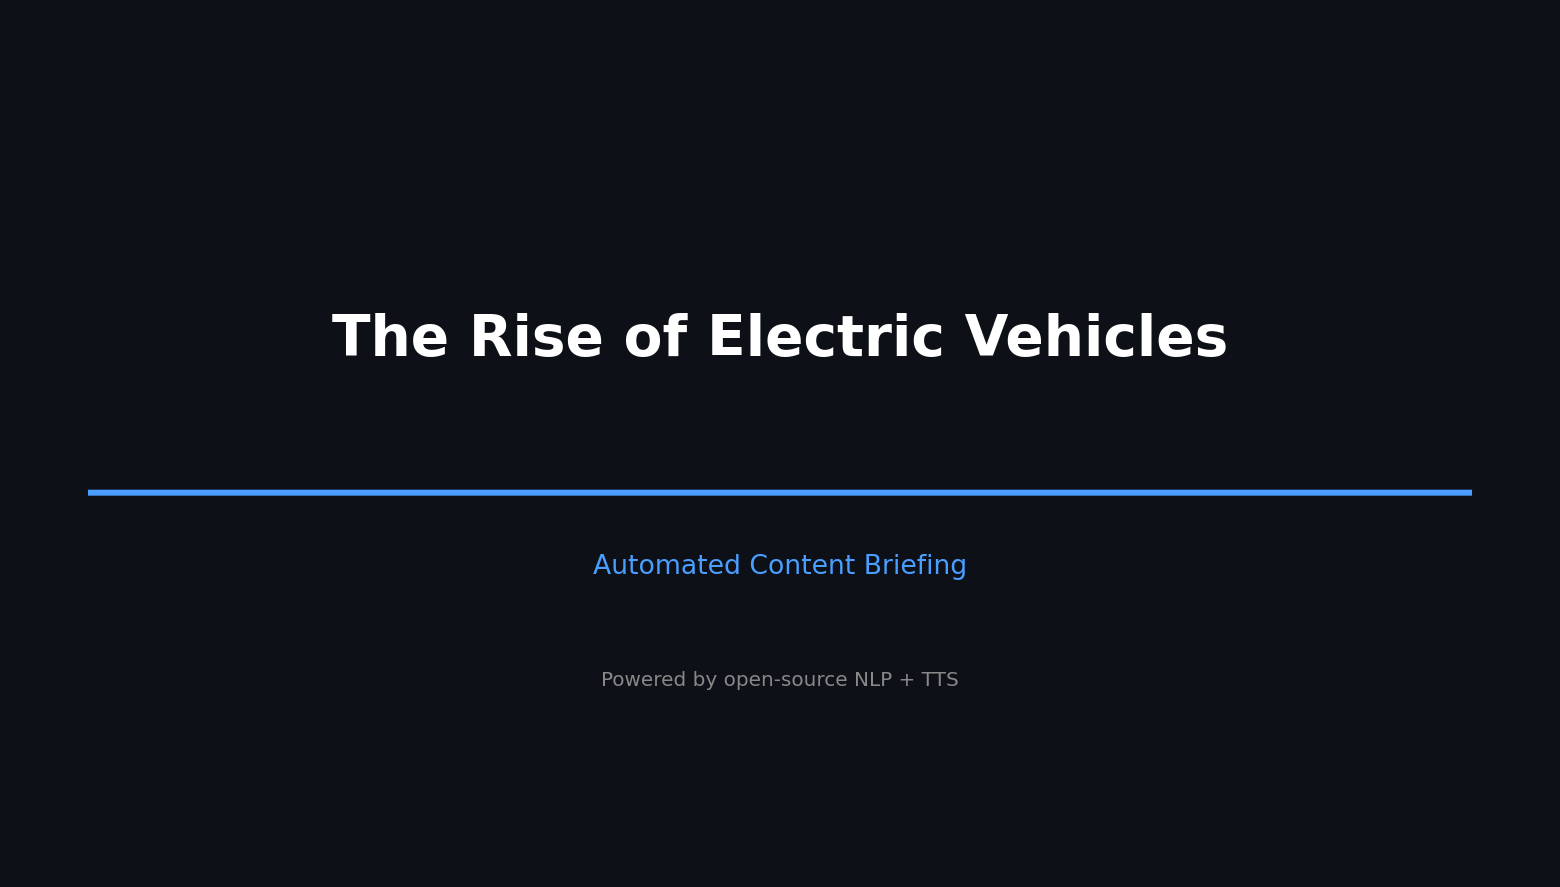

output/slide_01_introduction.png


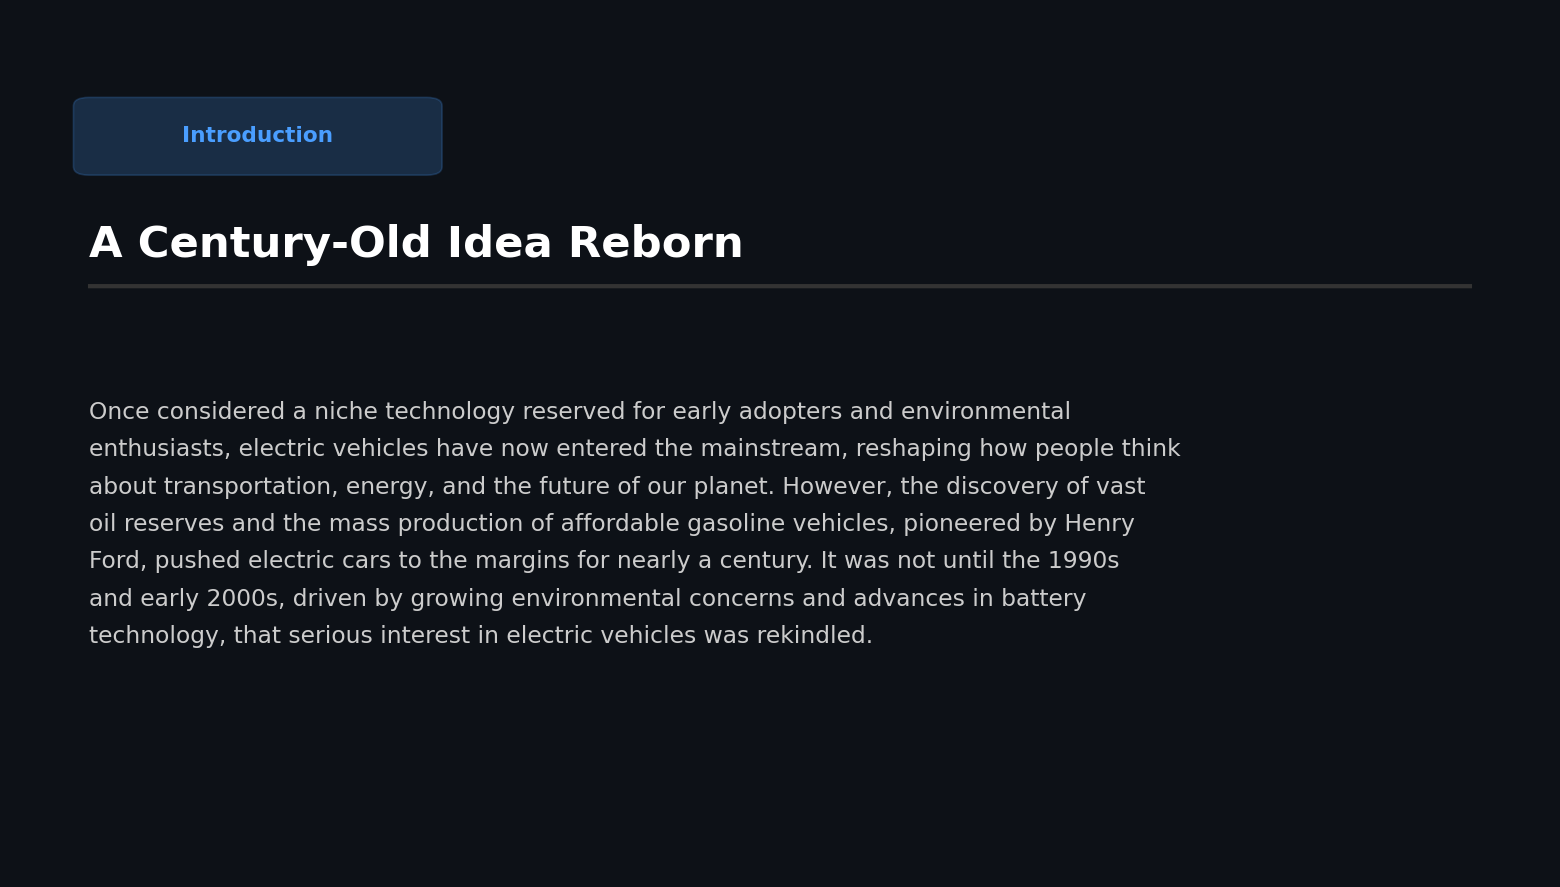

output/slide_02_the tesla effect.png


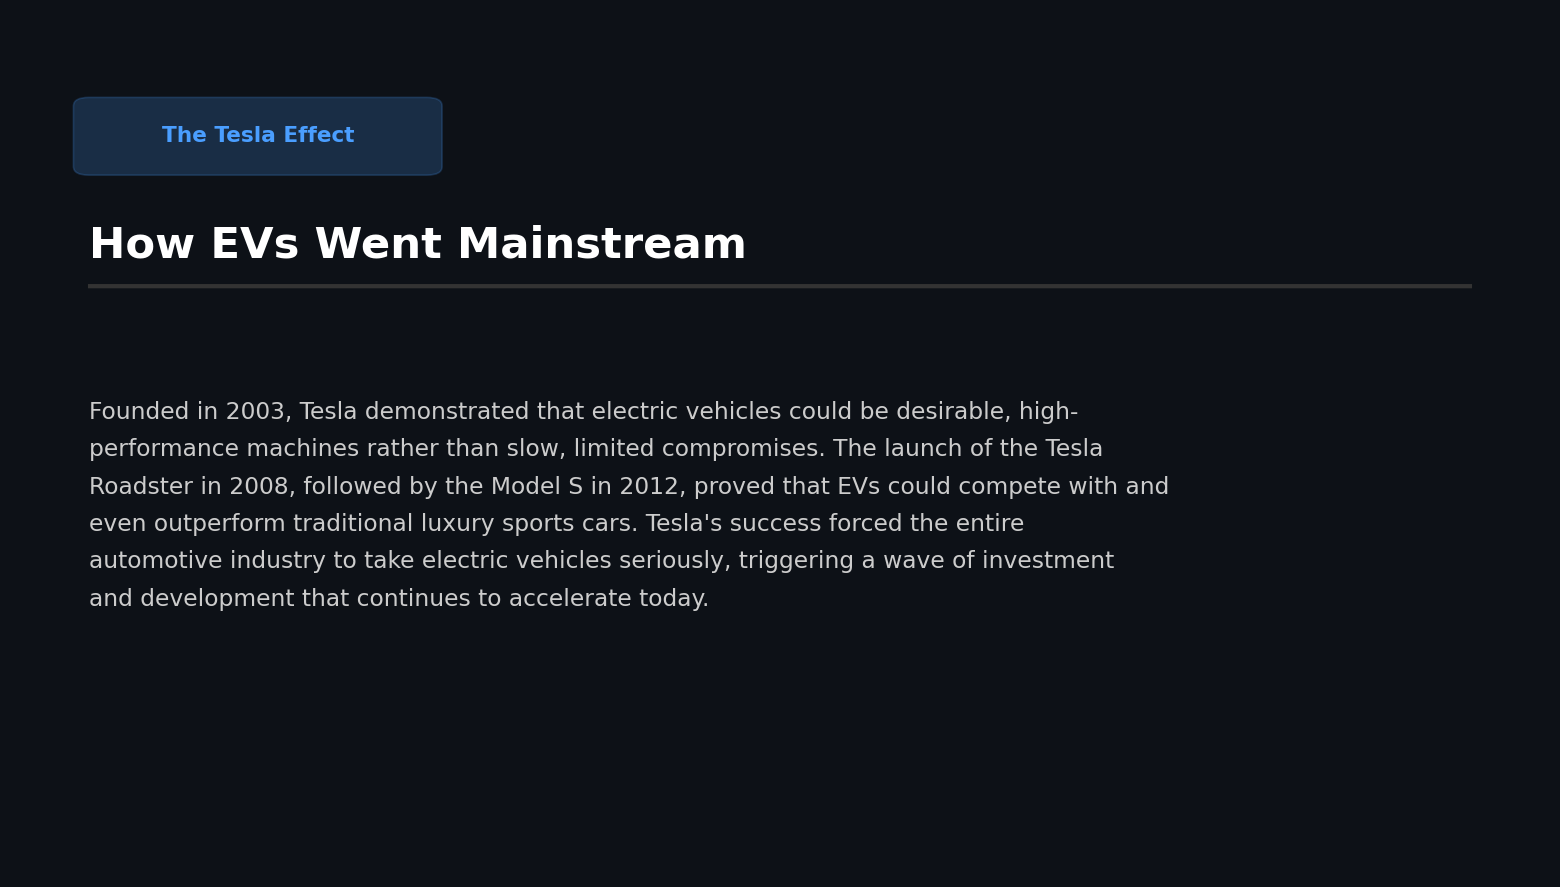

output/slide_03_key points.png


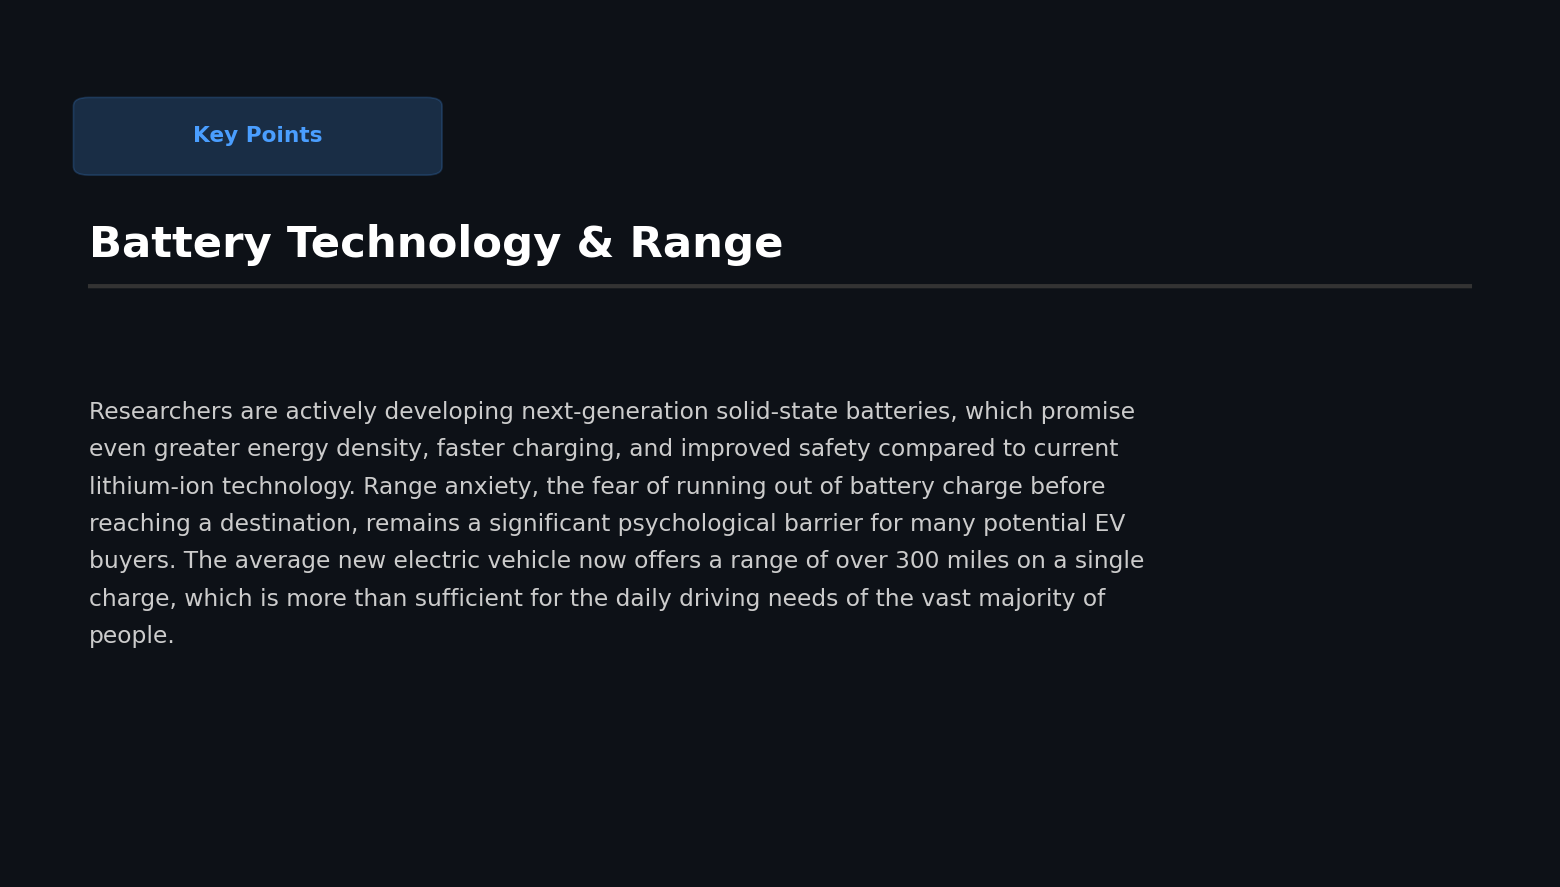

output/slide_04_policy & environment.png


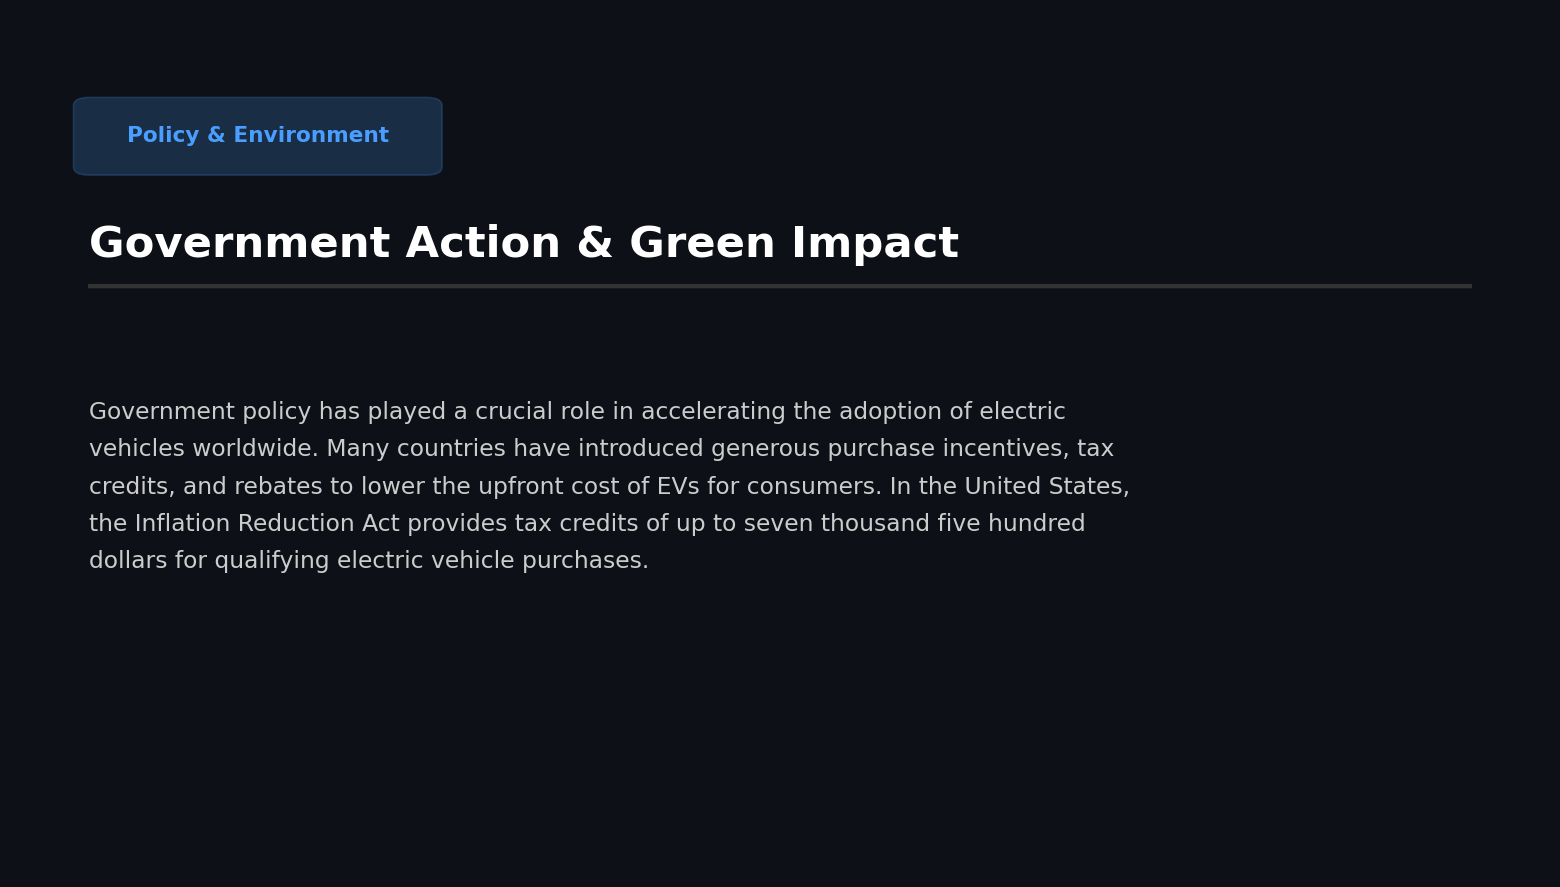

output/slide_05_summary.png


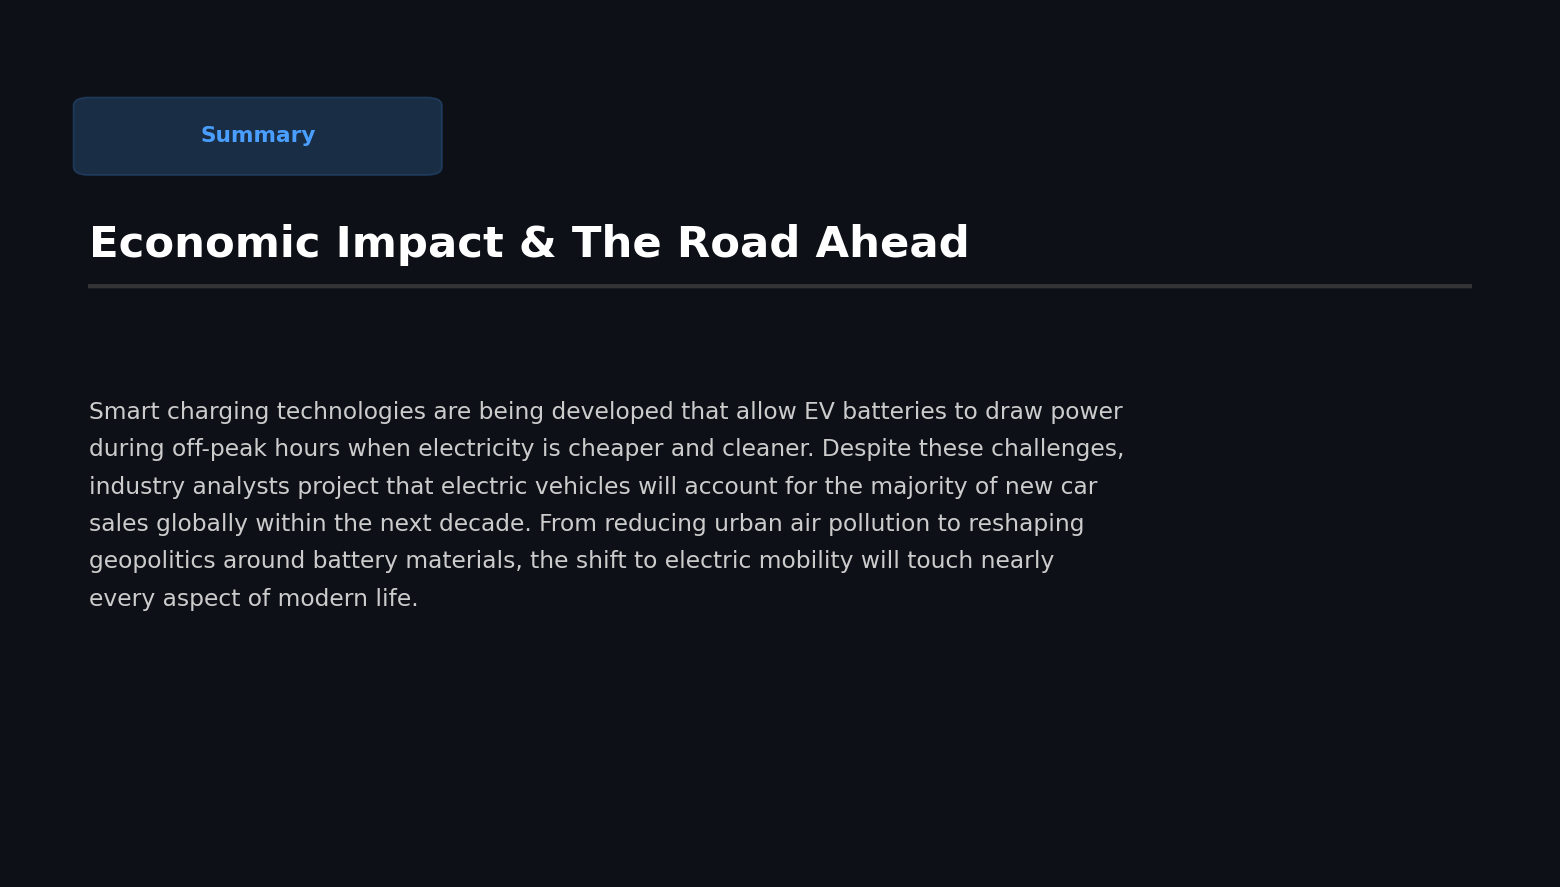

output/slide_05_end.png


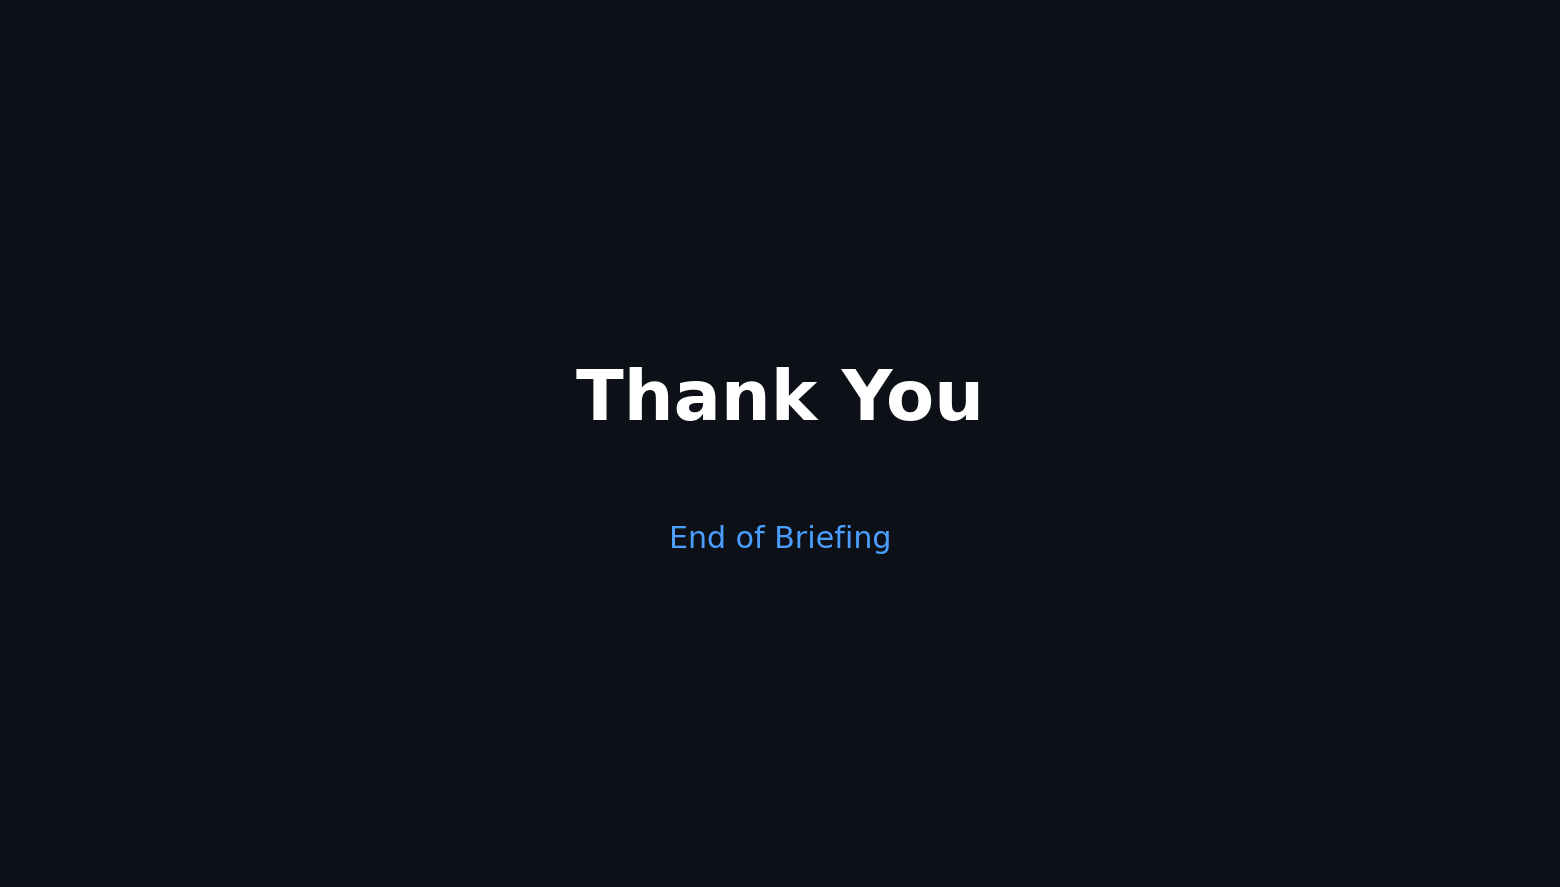

In [28]:
from IPython.display import Image, display

for slide in SLIDE_FILES:
    print(slide)
    display(Image(filename=slide, width=700))

---
## ✅ Done!
Your final video is at `output/briefing_final.mp4`.

**Pipeline Summary:**
| Step | Tool | Cost |
|------|------|------|
| Summarization | `sumy` (LSA) | Free |
| Text-to-Speech | `edge-tts` (Microsoft Neural) | Free |
| Slide Generation | `matplotlib` | Free |
| Video Assembly | `moviepy` + `ffmpeg` | Free |

**Total cost: $0.00**